In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm
import os

from torch.utils.data import Dataset, random_split, DataLoader, dataset

import pathlib
import matplotlib.patches as patches
from data.pets_dataset import OxfordIIITPetDataset, get_class_map

from models import MultiTaskPerceptionModel
from losses import DiceLoss, IoULoss

import wandb
wandb.init(project="Multitask-Pet-Detection")

In [2]:
multitask_model = MultiTaskPerceptionModel(num_breeds      = 37, 
                                           seg_classes     = 3, 
                                           in_channels     = 3, 
                                           classifier_path = "checkpoints/classifier.pth",
                                           localizer_path  = "checkpoints/localizer.pth",
                                           unet_path       = "checkpoints/unet.pth")


classifier loaded!
localizer loaded!
unet loaded!


In [3]:
mappings = get_class_map(pathlib.Path("oxford-iiit-pet"))

dataset = OxfordIIITPetDataset(root_dir = "oxford-iiit-pet")

train_ds, test_ds = random_split(dataset, [int(0.8 * len(dataset)), len(dataset)-int(0.8 * len(dataset))])

train_dl = DataLoader(train_ds, batch_size = 1, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size = 1, shuffle=True)


## 2.4 Inside the Black Box: Feature Maps

In [18]:
sample = next(iter(train_dl))
sample_image = sample["image"]

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

hooks = []

for name, layer in multitask_model.model_classifier.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        h = layer.register_forward_hook(get_activation(name))
        hooks.append(h)

_ = multitask_model.model_classifier(sample_image)

for h in hooks:
    h.remove()

activations.keys()

dict_keys(['conv_layers.0', 'conv_layers.4', 'conv_layers.8', 'conv_layers.11', 'conv_layers.15', 'conv_layers.18', 'conv_layers.22', 'conv_layers.25'])

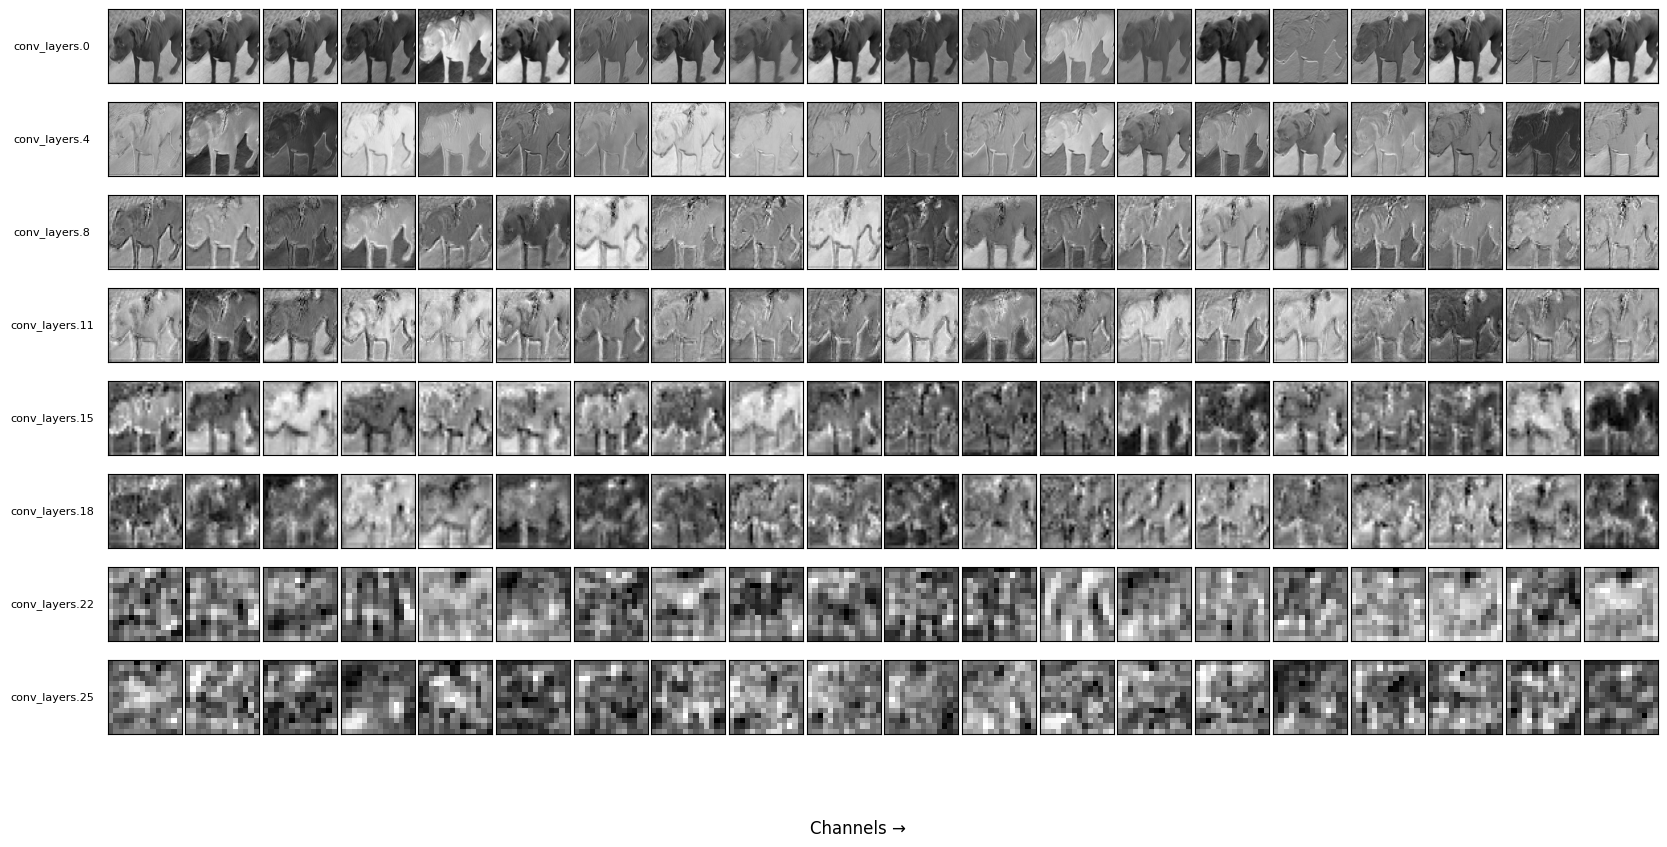

In [128]:
max_channels = 20
keys = list(activations.keys())

fig, axs = plt.subplots(
    len(keys), 
    max_channels, 
    figsize=(max_channels, 1.2 * len(keys))  
)

for i, key in enumerate(keys):
    act = activations[key][0] 
    C = act.shape[0]
    
    for j in range(max_channels):
        ax = axs[i, j] if len(keys) > 1 else axs[j]
        
        if j < C:
            img = act[j].cpu()
            img = (img - img.min()) / (img.max() - img.min() + 1e-5)
            ax.imshow(img, cmap='gray')
        else:
            ax.axis('off')
        
        ax.set_xticks([])
        ax.set_yticks([])
    
    axs[i, 0].set_ylabel(key, rotation=0, labelpad=40, fontsize=8, va='center')

fig.supxlabel("Channels →", fontsize=12)

plt.subplots_adjust(hspace=0.05, wspace=0.05)

plt.show()

## 2.1 The Regularization Effect of Dropout

In [4]:
sample = next(iter(train_dl))
sample_image = sample["image"]

activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

hooks = []

for name, layer in multitask_model.model_classifier.named_modules():
    if isinstance(layer, torch.nn.Conv2d):
        h = layer.register_forward_hook(get_activation(name))
        hooks.append(h)



_ = multitask_model.model_classifier(sample_image)

for h in hooks:
    h.remove()

activations.keys()

dict_keys(['conv_layers.0', 'conv_layers.4', 'conv_layers.8', 'conv_layers.11', 'conv_layers.15', 'conv_layers.18', 'conv_layers.22', 'conv_layers.25'])

In [ ]:
act = activations["conv_layers.8"]
vals = act.detach().flatten().cpu().numpy()

wandb.log({
    "Activation distribution": wandb.Histogram(vals, num_bins=100) 
})

wandb.finish()

In [17]:
from models.layers import CustomDropout

do = CustomDropout(p = 0)
(do(torch.rand(10, 10)) == 0).sum()/100

tensor(0.)